In [1]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from dynamic_routing_analysis import decoding_utils
# import dynamic_routing_analysis as dra
# import npc_lims

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
# %matplotlib inline
%matplotlib widget

In [18]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    )['session_id'].to_list()
    )

templeton_session_list=(
    session_table.filter(
    pl.col('project')=="Templeton",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    )['session_id'].to_list()
    )


In [3]:
predict_proba_pd = pd.read_parquet(r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\decode_context_strict_criteria_10_units_500ms_v272_2026-04-08\predict_proba_per_session_structure_with_unit_ids.parquet")

In [19]:
block_dprime_threshold=1.0

good_behavior_table={
    'session_id':[],
    'n_good_vis_blocks':[],
    'n_good_aud_blocks':[],
}

for sel_session in dr_session_list:
    
    n_good_vis_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_vis_blocks'].to_numpy()[0]>=block_dprime_threshold)
    n_good_aud_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_aud_blocks'].to_numpy()[0]>=block_dprime_threshold)

    good_behavior_table['session_id'].append(sel_session)
    good_behavior_table['n_good_vis_blocks'].append(n_good_vis_blocks)
    good_behavior_table['n_good_aud_blocks'].append(n_good_aud_blocks)

good_behavior_table=pd.DataFrame(good_behavior_table)
dr_good_behavior_list=good_behavior_table.query('n_good_vis_blocks>=2 and n_good_aud_blocks>=2')['session_id'].values

(102,)

In [24]:
sel_project='DynamicRouting'
sel_unit_subsample_size=20
sel_time_aligned_to='stim_start_time'
normalize_by_block=False
sel_bin_center=-0.25


all_performance=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/performance.parquet').collect().to_pandas()
all_trials=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/trials.parquet').collect().to_pandas()

# p(resp) versus p(vis context)

# list of sessions should just be an input to the eventual function
unique_sessions=session_table.to_pandas().query('project==@sel_project')['session_id'].unique()
if sel_project=='DynamicRouting':
    unique_sessions=dr_good_behavior_list

#performance criteria for DR

all_structures=[]

# #for each unique session
for ss,session_id in enumerate(unique_sessions):

    session_confidence=predict_proba_pd.query('session_id==@session_id and unit_subsample_size==@sel_unit_subsample_size and bin_center==@sel_bin_center')
    # session_confidence=predict_proba_pd.query('session_id==@session_id and unit_subsample_size==@sel_unit_subsample_size')
    session_structures=session_confidence['structure'].unique()

    if len(session_confidence)==0:
        print(f'session_id {session_id} has no predict_proba data, skipping...')
        continue

    session_labels=session_confidence['labels'].values[0] if 'labels' in session_confidence.columns else None

    #load trials table & performance table
    trials=all_trials.query('session_id==@session_id')
    performance=all_performance.query('session_id==@session_id')

    if len(session_confidence['predict_proba'].iloc[0])!=len(trials):
        print(f'session_id {session_id} has different number of trials than predict_proba table, skipping...')
        continue

    #### How to normalize response rate by block/session?? ###

    # block_norm_response_rate=np.full(len(trials), np.nan)
    # add blockwise and session-wide performance to trials table
    for block_index in trials['block_index'].unique():
        block_performance=performance.query('block_index==@block_index')
        trials.loc[trials['block_index']==block_index,'block_dprime']=block_performance['cross_modality_dprime'].values[0]

        # block_trial_idx=trials.query('block_index==@block_index')['trial_index'].values
        # block_trials=trials.query('block_index==@block_index')
        # block_response_rate=block_trials['is_response'].mean()
        # session_response_rate=trials

    trials['session_dprime']=performance['cross_modality_dprime'].mean()
    trials['session_id']=session_id
    trials['labels']=session_labels

    for structure in session_structures:
        # ss=session_structures[0]
        structure_confidence=session_confidence.query('structure==@structure')
        if len(structure_confidence)==0:
            continue
        structure_predict_proba=structure_confidence['predict_proba'].values[0]

        if normalize_by_block:
            block_normalized_predict_proba=np.full(len(trials), np.nan)
            for block_index in trials['block_index'].unique():
                block_trial_idx=trials.query('block_index==@block_index')['trial_index'].values
                block_normalized_predict_proba[block_trial_idx]=structure_predict_proba[block_trial_idx]-np.nanmean(structure_predict_proba[block_trial_idx])

            # trials[structure+'_predict_proba']=structure_predict_proba
            trials[structure+'_predict_proba']=block_normalized_predict_proba
        else:
            trials[structure+'_predict_proba']=structure_predict_proba

        if structure not in all_structures:
            all_structures.append(structure)

    if ss==0:
        all_trials_with_decoder_confidence=trials
    else:
        all_trials_with_decoder_confidence=pd.concat([all_trials_with_decoder_confidence,trials],axis=0,ignore_index=True)
        
# all_trials_with_decoder_confidence.to_parquet(
#     r'\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\time_mod_keep_units_consistent_0_2025-06-15\all_trials_with_predict_proba.parquet')


session_id 644866_2023-02-07 has no predict_proba data, skipping...
session_id 668755_2023-08-28 has no predict_proba data, skipping...
session_id 667252_2023-09-25 has no predict_proba data, skipping...
session_id 714753_2024-07-02 has no predict_proba data, skipping...
session_id 715710_2024-07-16 has no predict_proba data, skipping...
session_id 741137_2024-10-10 has no predict_proba data, skipping...
session_id 741148_2024-10-18 has no predict_proba data, skipping...
session_id 742903_2024-10-21 has no predict_proba data, skipping...
session_id 761583_2024-12-17 has different number of trials than predict_proba table, skipping...


In [25]:
sel_structure='MOs'


def remove_indices_if_out_of_bounds(indices, array_length):
    return indices[(indices >= 0) & (indices < array_length)]

# flip aud block predict proba — build as column on the DataFrame for guaranteed alignment

structure_predict_proba=all_trials_with_decoder_confidence[sel_structure+'_predict_proba'].values

# iterate over ALL sessions present in the DataFrame (not just dr_session_list)
session_ids=all_trials_with_decoder_confidence['session_id'].unique()
# session_ids=templeton_session_list

adj_structure_predict_proba=np.full(len(all_trials_with_decoder_confidence), np.nan)

for session_id in session_ids:
    session_mask=all_trials_with_decoder_confidence['session_id']==session_id
    session_predict_proba=structure_predict_proba[session_mask]
    session_block_index=all_trials_with_decoder_confidence.loc[session_mask,'block_index'].values
    session_is_vis_rewarded=all_trials_with_decoder_confidence.loc[session_mask,'labels'].values

    flipped_session_predict_proba=decoding_utils.flip_auditory_blocks(
        session_predict_proba, 
        session_block_index, 
        session_is_vis_rewarded, 
        input_type='predict_proba')

    adj_structure_predict_proba[session_mask]=flipped_session_predict_proba

all_trials_with_decoder_confidence['adj_predict_proba']=adj_structure_predict_proba

# compute next-trial predict_proba with session-boundary guard (Fix 2)
adj_predict_proba_next=np.full(len(all_trials_with_decoder_confidence), np.nan)
session_ids_arr=all_trials_with_decoder_confidence['session_id'].values
for i in range(len(adj_structure_predict_proba)-1):
    if session_ids_arr[i]==session_ids_arr[i+1]:
        adj_predict_proba_next[i]=adj_structure_predict_proba[i+1]
all_trials_with_decoder_confidence['adj_predict_proba_next']=adj_predict_proba_next

# extract per-trial-type indices and values using aligned DataFrame columns
hit_mask=all_trials_with_decoder_confidence.eval('is_hit and is_target')
fa_mask=all_trials_with_decoder_confidence.eval('is_false_alarm and is_target')
cr_mask=all_trials_with_decoder_confidence.eval('is_correct_reject and is_target')

vis_hit_mask=all_trials_with_decoder_confidence.eval('is_hit and is_vis_target')
aud_hit_mask=all_trials_with_decoder_confidence.eval('is_hit and is_aud_target')
vis_fa_mask=all_trials_with_decoder_confidence.eval('is_false_alarm and is_vis_target')
aud_fa_mask=all_trials_with_decoder_confidence.eval('is_false_alarm and is_aud_target')
vis_cr_mask=all_trials_with_decoder_confidence.eval('is_correct_reject and is_vis_target')
aud_cr_mask=all_trials_with_decoder_confidence.eval('is_correct_reject and is_aud_target')

nontarget_nonresponse_mask=all_trials_with_decoder_confidence.eval('~is_response and is_nontarget')
vis_nontarget_nonresponse_mask=all_trials_with_decoder_confidence.eval('~is_response and is_vis_nontarget')
aud_nontarget_nonresponse_mask=all_trials_with_decoder_confidence.eval('~is_response and is_aud_nontarget')

vis_target_vis_block_response_mask=all_trials_with_decoder_confidence.eval('is_vis_target and is_vis_rewarded and is_response')
vis_target_aud_block_response_mask=all_trials_with_decoder_confidence.eval('is_vis_target and ~is_vis_rewarded and is_response')
aud_target_aud_block_response_mask=all_trials_with_decoder_confidence.eval('is_aud_target and ~is_vis_rewarded and is_response')
aud_target_vis_block_response_mask=all_trials_with_decoder_confidence.eval('is_aud_target and is_vis_rewarded and is_response')

# get pre/post predict proba for every trial type of interest
hit_predict_proba=all_trials_with_decoder_confidence.loc[hit_mask,'adj_predict_proba'].values
hit_predict_proba_next=all_trials_with_decoder_confidence.loc[hit_mask,'adj_predict_proba_next'].values
fa_predict_proba=all_trials_with_decoder_confidence.loc[fa_mask,'adj_predict_proba'].values
fa_predict_proba_next=all_trials_with_decoder_confidence.loc[fa_mask,'adj_predict_proba_next'].values
cr_predict_proba=all_trials_with_decoder_confidence.loc[cr_mask,'adj_predict_proba'].values
cr_predict_proba_next=all_trials_with_decoder_confidence.loc[cr_mask,'adj_predict_proba_next'].values
nontarget_nonresponse_predict_proba=all_trials_with_decoder_confidence.loc[nontarget_nonresponse_mask,'adj_predict_proba'].values
nontarget_nonresponse_predict_proba_next=all_trials_with_decoder_confidence.loc[nontarget_nonresponse_mask,'adj_predict_proba_next'].values

vis_hit_predict_proba=all_trials_with_decoder_confidence.loc[vis_hit_mask,'adj_predict_proba'].values
vis_hit_predict_proba_next=all_trials_with_decoder_confidence.loc[vis_hit_mask,'adj_predict_proba_next'].values
aud_hit_predict_proba=all_trials_with_decoder_confidence.loc[aud_hit_mask,'adj_predict_proba'].values
aud_hit_predict_proba_next=all_trials_with_decoder_confidence.loc[aud_hit_mask,'adj_predict_proba_next'].values
vis_fa_predict_proba=all_trials_with_decoder_confidence.loc[vis_fa_mask,'adj_predict_proba'].values
vis_fa_predict_proba_next=all_trials_with_decoder_confidence.loc[vis_fa_mask,'adj_predict_proba_next'].values
aud_fa_predict_proba=all_trials_with_decoder_confidence.loc[aud_fa_mask,'adj_predict_proba'].values
aud_fa_predict_proba_next=all_trials_with_decoder_confidence.loc[aud_fa_mask,'adj_predict_proba_next'].values
vis_cr_predict_proba=all_trials_with_decoder_confidence.loc[vis_cr_mask,'adj_predict_proba'].values
vis_cr_predict_proba_next=all_trials_with_decoder_confidence.loc[vis_cr_mask,'adj_predict_proba_next'].values
aud_cr_predict_proba=all_trials_with_decoder_confidence.loc[aud_cr_mask,'adj_predict_proba'].values
aud_cr_predict_proba_next=all_trials_with_decoder_confidence.loc[aud_cr_mask,'adj_predict_proba_next'].values

vis_nontarget_nonresponse_predict_proba=all_trials_with_decoder_confidence.loc[vis_nontarget_nonresponse_mask,'adj_predict_proba'].values
vis_nontarget_nonresponse_predict_proba_next=all_trials_with_decoder_confidence.loc[vis_nontarget_nonresponse_mask,'adj_predict_proba_next'].values
aud_nontarget_nonresponse_predict_proba=all_trials_with_decoder_confidence.loc[aud_nontarget_nonresponse_mask,'adj_predict_proba'].values
aud_nontarget_nonresponse_predict_proba_next=all_trials_with_decoder_confidence.loc[aud_nontarget_nonresponse_mask,'adj_predict_proba_next'].values

vis_target_vis_block_response_predict_proba=all_trials_with_decoder_confidence.loc[vis_target_vis_block_response_mask,'adj_predict_proba'].values
vis_target_vis_block_response_predict_proba_next=all_trials_with_decoder_confidence.loc[vis_target_vis_block_response_mask,'adj_predict_proba_next'].values
vis_target_aud_block_response_predict_proba=all_trials_with_decoder_confidence.loc[vis_target_aud_block_response_mask,'adj_predict_proba'].values
vis_target_aud_block_response_predict_proba_next=all_trials_with_decoder_confidence.loc[vis_target_aud_block_response_mask,'adj_predict_proba_next'].values
aud_target_aud_block_response_predict_proba=all_trials_with_decoder_confidence.loc[aud_target_aud_block_response_mask,'adj_predict_proba'].values
aud_target_aud_block_response_predict_proba_next=all_trials_with_decoder_confidence.loc[aud_target_aud_block_response_mask,'adj_predict_proba_next'].values
aud_target_vis_block_response_predict_proba=all_trials_with_decoder_confidence.loc[aud_target_vis_block_response_mask,'adj_predict_proba'].values
aud_target_vis_block_response_predict_proba_next=all_trials_with_decoder_confidence.loc[aud_target_vis_block_response_mask,'adj_predict_proba_next'].values

print(f"Total trials: {len(all_trials_with_decoder_confidence)}, adj_predict_proba length: {len(adj_structure_predict_proba)}")
print(f"Sessions in DataFrame: {len(session_ids)}")
print(f"Cross-session boundaries dropped (NaN in next): {np.isnan(adj_predict_proba_next).sum() - np.isnan(adj_structure_predict_proba).sum()}")

Total trials: 48829, adj_predict_proba length: 48829
Sessions in DataFrame: 93
Cross-session boundaries dropped (NaN in next): 40


In [37]:
# use_shared_bins: if True, compute one set of percentile bin edges across ALL trial types combined
# if False, compute percentile bins independently for each trial type (original behavior)
use_shared_bins = True

# compute shared bins from all valid predict_proba values (used only if use_shared_bins=True)
if use_shared_bins:
    all_valid_pp = adj_structure_predict_proba[~np.isnan(adj_structure_predict_proba)]
    shared_baseline_bins = np.percentile(all_valid_pp, [0, 20, 40, 60, 80, 100])

hit_df=pd.DataFrame({
    'predict_proba': hit_predict_proba,
    'predict_proba_next': hit_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[hit_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[hit_mask,'block_index'].values,
})

if use_shared_bins:
    hit_baseline_bins = shared_baseline_bins
else:
    hit_baseline_bins=np.percentile(hit_predict_proba[~np.isnan(hit_predict_proba)],[0,20,40,60,80,100])
hit_df['baseline_bin']=pd.cut(hit_df['predict_proba'], bins=hit_baseline_bins, labels=False, include_lowest=True)

fa_df=pd.DataFrame({
    'predict_proba': fa_predict_proba,
    'predict_proba_next': fa_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[fa_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[fa_mask,'block_index'].values,
})

if len(fa_predict_proba)>0:
    if use_shared_bins:
        fa_baseline_bins = shared_baseline_bins
    else:
        fa_baseline_bins=np.percentile(fa_predict_proba[~np.isnan(fa_predict_proba)],[0,20,40,60,80,100])
    fa_df['baseline_bin']=pd.cut(fa_df['predict_proba'], bins=fa_baseline_bins, labels=False, include_lowest=True)
else:
    print('No FA trials found, skipping baseline binning for FA dataframe')
    fa_df['baseline_bin']=np.nan
    fa_baseline_bins = shared_baseline_bins if use_shared_bins else np.array([0,0.2,0.4,0.6,0.8,1.0])

cr_df=pd.DataFrame({
    'predict_proba': cr_predict_proba,
    'predict_proba_next': cr_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[cr_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[cr_mask,'block_index'].values,
})

if len(cr_predict_proba)>0:
    if use_shared_bins:
        cr_baseline_bins = shared_baseline_bins
    else:
        cr_baseline_bins=np.percentile(cr_predict_proba[~np.isnan(cr_predict_proba)],[0,20,40,60,80,100])
    cr_df['baseline_bin']=pd.cut(cr_df['predict_proba'], bins=cr_baseline_bins, labels=False, include_lowest=True)
else:
    print('No CR trials found, skipping baseline binning for CR dataframe')
    cr_df['baseline_bin']=np.nan
    cr_baseline_bins = shared_baseline_bins if use_shared_bins else np.array([0,0.2,0.4,0.6,0.8,1.0])

nontarget_nonresponse_df=pd.DataFrame({
    'predict_proba': nontarget_nonresponse_predict_proba,
    'predict_proba_next': nontarget_nonresponse_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[nontarget_nonresponse_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[nontarget_nonresponse_mask,'block_index'].values,
})

if use_shared_bins:
    nontarget_nonresponse_baseline_bins = shared_baseline_bins
else:
    nontarget_nonresponse_baseline_bins=np.percentile(nontarget_nonresponse_predict_proba[~np.isnan(nontarget_nonresponse_predict_proba)],[0,20,40,60,80,100])
nontarget_nonresponse_df['baseline_bin']=pd.cut(nontarget_nonresponse_df['predict_proba'], bins=nontarget_nonresponse_baseline_bins, labels=False, include_lowest=True)


#session-wise averages
hit_session_avg=hit_df.groupby(['session_id','baseline_bin'])[['predict_proba','predict_proba_next']].mean().reset_index()
fa_session_avg=fa_df.groupby(['session_id','baseline_bin'])[['predict_proba','predict_proba_next']].mean().reset_index()
cr_session_avg=cr_df.groupby(['session_id','baseline_bin'])[['predict_proba','predict_proba_next']].mean().reset_index()
nontarget_nonresponse_session_avg=nontarget_nonresponse_df.groupby(['session_id','baseline_bin'])[['predict_proba','predict_proba_next']].mean().reset_index()


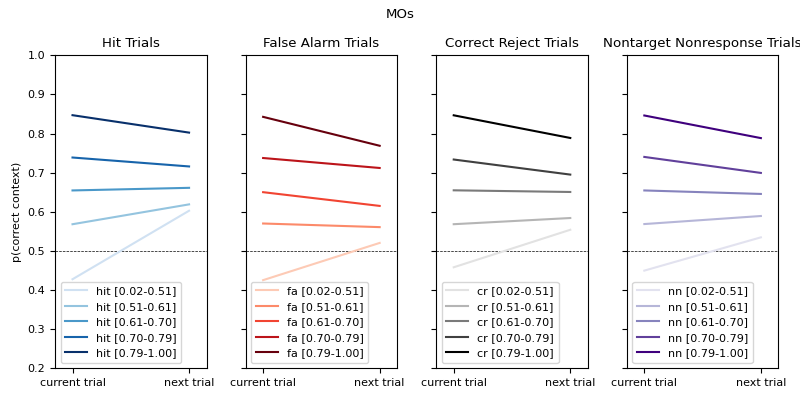

In [34]:
hit_colors=np.linspace(0.2,1.0,len(hit_baseline_bins)-1)
fa_colors=np.linspace(0.2,1.0,len(fa_baseline_bins)-1)#[::-1]
cr_colors=np.linspace(0.2,1.0,len(cr_baseline_bins)-1)
nn_colors=np.linspace(0.2,1.0,len(nontarget_nonresponse_baseline_bins)-1)#[::-1]

fig,ax=plt.subplots(1,4,figsize=(8,4),sharex=True,sharey=True)
ax[0].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[1].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[2].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[3].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
# ax.axvline(0,color='k',linewidth=0.5,linestyle='--')

for bb in range(len(hit_baseline_bins)-1):
    bin_hits=hit_df.query(f'baseline_bin=={bb}')
    if bin_hits.shape[0]>0:
        ax[0].plot([0,1], [np.nanmedian(bin_hits['predict_proba']), np.nanmedian(bin_hits['predict_proba_next'])], 
                label=f'hit [{hit_baseline_bins[bb]:.2f}-{hit_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Blues(hit_colors[bb]))


for bb in range(len(fa_baseline_bins)-1):
    bin_fas=fa_df.query(f'baseline_bin=={bb}')
    if bin_fas.shape[0]>0:
        ax[1].plot([0,1], [np.nanmedian(bin_fas['predict_proba']), np.nanmedian(bin_fas['predict_proba_next'])], 
                label=f'fa [{fa_baseline_bins[bb]:.2f}-{fa_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Reds(fa_colors[bb]))

for bb in range(len(cr_baseline_bins)-1):
    bin_crs=cr_df.query(f'baseline_bin=={bb}')
    if bin_crs.shape[0]>0:
        ax[2].plot([0,1], [np.nanmedian(bin_crs['predict_proba']), np.nanmedian(bin_crs['predict_proba_next'])], 
                label=f'cr [{cr_baseline_bins[bb]:.2f}-{cr_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Greys(cr_colors[bb]))
        
for bb in range(len(nontarget_nonresponse_baseline_bins)-1):
    bin_nns=nontarget_nonresponse_df.query(f'baseline_bin=={bb}')
    if bin_nns.shape[0]>0:
        ax[3].plot([0,1], [np.nanmedian(bin_nns['predict_proba']), np.nanmedian(bin_nns['predict_proba_next'])], 
                label=f'nn [{nontarget_nonresponse_baseline_bins[bb]:.2f}-{nontarget_nonresponse_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Purples(nn_colors[bb]))


ax[0].set_xticks([0,1])
ax[0].set_xticklabels(['current trial', 'next trial'])
ax[0].set_xlim(-0.15,1.15)
ax[0].set_ylim(0.2,1.0)
ax[0].set_ylabel('p(correct context)')
ax[0].set_title('Hit Trials')
ax[0].legend()

ax[1].set_xticks([0,1])
ax[1].set_xticklabels(['current trial', 'next trial'])
ax[1].set_title('False Alarm Trials')
ax[1].legend()

ax[2].set_xticks([0,1])
ax[2].set_xticklabels(['current trial', 'next trial'])
ax[2].set_title('Correct Reject Trials')
ax[2].legend()

ax[3].set_xticks([0,1])
ax[3].set_xticklabels(['current trial', 'next trial'])
ax[3].set_title('Nontarget Nonresponse Trials')
ax[3].legend()

fig.suptitle(f"{sel_structure}")
fig.tight_layout()

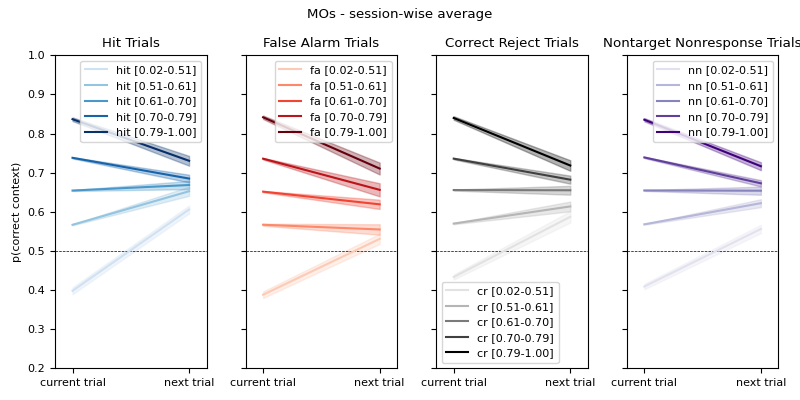

In [41]:
#session wise average

hit_colors=np.linspace(0.2,1.0,len(hit_baseline_bins)-1)
fa_colors=np.linspace(0.2,1.0,len(fa_baseline_bins)-1)#[::-1]
cr_colors=np.linspace(0.2,1.0,len(cr_baseline_bins)-1)
nn_colors=np.linspace(0.2,1.0,len(nontarget_nonresponse_baseline_bins)-1)#[::-1]

fig,ax=plt.subplots(1,4,figsize=(8,4),sharex=True,sharey=True)
ax[0].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[1].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[2].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[3].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
# ax.axvline(0,color='k',linewidth=0.5,linestyle='--')

for bb in range(len(hit_baseline_bins)-1):
    bin_hits=hit_session_avg.query(f'baseline_bin=={bb}')
    if bin_hits.shape[0]>0:
        ax[0].plot([0,1], [np.nanmean(bin_hits['predict_proba']), np.nanmean(bin_hits['predict_proba_next'])], 
                label=f'hit [{hit_baseline_bins[bb]:.2f}-{hit_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Blues(hit_colors[bb]))
        ax[0].fill_between([0,1],
                [np.nanmean(bin_hits['predict_proba'])-stats.sem(bin_hits['predict_proba']), np.nanmean(bin_hits['predict_proba_next'])-stats.sem(bin_hits['predict_proba_next'])],
                [np.nanmean(bin_hits['predict_proba'])+stats.sem(bin_hits['predict_proba']), np.nanmean(bin_hits['predict_proba_next'])+stats.sem(bin_hits['predict_proba_next'])],
                color=plt.cm.Blues(hit_colors[bb]), alpha=0.3)


for bb in range(len(fa_baseline_bins)-1):
    bin_fas=fa_session_avg.query(f'baseline_bin=={bb}')
    if bin_fas.shape[0]>0:
        ax[1].plot([0,1], [np.nanmean(bin_fas['predict_proba']), np.nanmean(bin_fas['predict_proba_next'])], 
                label=f'fa [{fa_baseline_bins[bb]:.2f}-{fa_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Reds(fa_colors[bb]))
        ax[1].fill_between([0,1],
                [np.nanmean(bin_fas['predict_proba'])-stats.sem(bin_fas['predict_proba']), np.nanmean(bin_fas['predict_proba_next'])-stats.sem(bin_fas['predict_proba_next'])],
                [np.nanmean(bin_fas['predict_proba'])+stats.sem(bin_fas['predict_proba']), np.nanmean(bin_fas['predict_proba_next'])+stats.sem(bin_fas['predict_proba_next'])],
                color=plt.cm.Reds(fa_colors[bb]), alpha=0.3)


for bb in range(len(cr_baseline_bins)-1):
    bin_crs=cr_session_avg.query(f'baseline_bin=={bb}')
    if bin_crs.shape[0]>0:
        ax[2].plot([0,1], [np.nanmean(bin_crs['predict_proba']), np.nanmean(bin_crs['predict_proba_next'])], 
                label=f'cr [{cr_baseline_bins[bb]:.2f}-{cr_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Greys(cr_colors[bb]))
        ax[2].fill_between([0,1],
                [np.nanmean(bin_crs['predict_proba'])-stats.sem(bin_crs['predict_proba']), np.nanmean(bin_crs['predict_proba_next'])-stats.sem(bin_crs['predict_proba_next'])],
                [np.nanmean(bin_crs['predict_proba'])+stats.sem(bin_crs['predict_proba']), np.nanmean(bin_crs['predict_proba_next'])+stats.sem(bin_crs['predict_proba_next'])],
                color=plt.cm.Greys(cr_colors[bb]), alpha=0.3)
        
for bb in range(len(nontarget_nonresponse_baseline_bins)-1):
    bin_nns=nontarget_nonresponse_session_avg.query(f'baseline_bin=={bb}')
    if bin_nns.shape[0]>0:
        ax[3].plot([0,1], [np.nanmean(bin_nns['predict_proba']), np.nanmean(bin_nns['predict_proba_next'])], 
                label=f'nn [{nontarget_nonresponse_baseline_bins[bb]:.2f}-{nontarget_nonresponse_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Purples(nn_colors[bb]))
        ax[3].fill_between([0,1],
                [np.nanmean(bin_nns['predict_proba'])-stats.sem(bin_nns['predict_proba']), np.nanmean(bin_nns['predict_proba_next'])-stats.sem(bin_nns['predict_proba_next'])],
                [np.nanmean(bin_nns['predict_proba'])+stats.sem(bin_nns['predict_proba']), np.nanmean(bin_nns['predict_proba_next'])+stats.sem(bin_nns['predict_proba_next'])],
                color=plt.cm.Purples(nn_colors[bb]), alpha=0.3)


ax[0].set_xticks([0,1])
ax[0].set_xticklabels(['current trial', 'next trial'])
ax[0].set_xlim(-0.15,1.15)
ax[0].set_ylim(0.2,1.0)
ax[0].set_ylabel('p(correct context)')
ax[0].set_title('Hit Trials')
ax[0].legend()

ax[1].set_xticks([0,1])
ax[1].set_xticklabels(['current trial', 'next trial'])
ax[1].set_title('False Alarm Trials')
ax[1].legend()

ax[2].set_xticks([0,1])
ax[2].set_xticklabels(['current trial', 'next trial'])
ax[2].set_title('Correct Reject Trials')
ax[2].legend()

ax[3].set_xticks([0,1])
ax[3].set_xticklabels(['current trial', 'next trial'])
ax[3].set_title('Nontarget Nonresponse Trials')
ax[3].legend()

fig.suptitle(f"{sel_structure} - session-wise average")
fig.tight_layout()

In [28]:
# make dfs for other more specific trial types
vis_hit_df=pd.DataFrame({
    'predict_proba': vis_hit_predict_proba,
    'predict_proba_next': vis_hit_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[vis_hit_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[vis_hit_mask,'block_index'].values,
})
if use_shared_bins:
    vis_hit_baseline_bins = shared_baseline_bins
else:
    vis_hit_baseline_bins=np.percentile(vis_hit_predict_proba[~np.isnan(vis_hit_predict_proba)],[0,20,40,60,80,100])
vis_hit_df['baseline_bin']=pd.cut(vis_hit_df['predict_proba'], bins=vis_hit_baseline_bins, labels=False, include_lowest=True)

aud_hit_df=pd.DataFrame({
    'predict_proba': aud_hit_predict_proba,
    'predict_proba_next': aud_hit_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[aud_hit_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[aud_hit_mask,'block_index'].values,
})
if use_shared_bins:
    aud_hit_baseline_bins = shared_baseline_bins
else:
    aud_hit_baseline_bins=np.percentile(aud_hit_predict_proba[~np.isnan(aud_hit_predict_proba)],[0,20,40,60,80,100])
aud_hit_df['baseline_bin']=pd.cut(aud_hit_df['predict_proba'], bins=aud_hit_baseline_bins, labels=False, include_lowest=True)

vis_fa_df=pd.DataFrame({
    'predict_proba': vis_fa_predict_proba,
    'predict_proba_next': vis_fa_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[vis_fa_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[vis_fa_mask,'block_index'].values,
})
if use_shared_bins:
    vis_fa_baseline_bins = shared_baseline_bins
else:
    vis_fa_baseline_bins=np.percentile(vis_fa_predict_proba[~np.isnan(vis_fa_predict_proba)],[0,20,40,60,80,100])
vis_fa_df['baseline_bin']=pd.cut(vis_fa_df['predict_proba'], bins=vis_fa_baseline_bins, labels=False, include_lowest=True)

aud_fa_df=pd.DataFrame({
    'predict_proba': aud_fa_predict_proba,
    'predict_proba_next': aud_fa_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[aud_fa_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[aud_fa_mask,'block_index'].values,
})
if use_shared_bins:
    aud_fa_baseline_bins = shared_baseline_bins
else:
    aud_fa_baseline_bins=np.percentile(aud_fa_predict_proba[~np.isnan(aud_fa_predict_proba)],[0,20,40,60,80,100])
aud_fa_df['baseline_bin']=pd.cut(aud_fa_df['predict_proba'], bins=aud_fa_baseline_bins, labels=False, include_lowest=True)

vis_cr_df=pd.DataFrame({
    'predict_proba': vis_cr_predict_proba,
    'predict_proba_next': vis_cr_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[vis_cr_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[vis_cr_mask,'block_index'].values,
})
if use_shared_bins:
    vis_cr_baseline_bins = shared_baseline_bins
else:
    vis_cr_baseline_bins=np.percentile(vis_cr_predict_proba[~np.isnan(vis_cr_predict_proba)],[0,20,40,60,80,100])
vis_cr_df['baseline_bin']=pd.cut(vis_cr_df['predict_proba'], bins=vis_cr_baseline_bins, labels=False, include_lowest=True)

aud_cr_df=pd.DataFrame({
    'predict_proba': aud_cr_predict_proba,
    'predict_proba_next': aud_cr_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[aud_cr_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[aud_cr_mask,'block_index'].values,
})
if use_shared_bins:
    aud_cr_baseline_bins = shared_baseline_bins
else:
    aud_cr_baseline_bins=np.percentile(aud_cr_predict_proba[~np.isnan(aud_cr_predict_proba)],[0,20,40,60,80,100])
aud_cr_df['baseline_bin']=pd.cut(aud_cr_df['predict_proba'], bins=aud_cr_baseline_bins, labels=False, include_lowest=True)

vis_nontarget_nonresponse_df=pd.DataFrame({
    'predict_proba': vis_nontarget_nonresponse_predict_proba,
    'predict_proba_next': vis_nontarget_nonresponse_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[vis_nontarget_nonresponse_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[vis_nontarget_nonresponse_mask,'block_index'].values,
})
if use_shared_bins:
    vis_nontarget_nonresponse_baseline_bins = shared_baseline_bins
else:
    vis_nontarget_nonresponse_baseline_bins=np.percentile(vis_nontarget_nonresponse_predict_proba[~np.isnan(vis_nontarget_nonresponse_predict_proba)],[0,20,40,60,80,100])
vis_nontarget_nonresponse_df['baseline_bin']=pd.cut(vis_nontarget_nonresponse_df['predict_proba'], bins=vis_nontarget_nonresponse_baseline_bins, labels=False, include_lowest=True)

aud_nontarget_nonresponse_df=pd.DataFrame({
    'predict_proba': aud_nontarget_nonresponse_predict_proba,
    'predict_proba_next': aud_nontarget_nonresponse_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[aud_nontarget_nonresponse_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[aud_nontarget_nonresponse_mask,'block_index'].values,
})
if use_shared_bins:
    aud_nontarget_nonresponse_baseline_bins = shared_baseline_bins
else:
    aud_nontarget_nonresponse_baseline_bins=np.percentile(aud_nontarget_nonresponse_predict_proba[~np.isnan(aud_nontarget_nonresponse_predict_proba)],[0,20,40,60,80,100])
aud_nontarget_nonresponse_df['baseline_bin']=pd.cut(aud_nontarget_nonresponse_df['predict_proba'], bins=aud_nontarget_nonresponse_baseline_bins, labels=False, include_lowest=True)

vis_target_vis_block_response_df=pd.DataFrame({
    'predict_proba': vis_target_vis_block_response_predict_proba,
    'predict_proba_next': vis_target_vis_block_response_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[vis_target_vis_block_response_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[vis_target_vis_block_response_mask,'block_index'].values,
})
if use_shared_bins:
    vis_target_vis_block_response_baseline_bins = shared_baseline_bins
else:
    vis_target_vis_block_response_baseline_bins=np.percentile(vis_target_vis_block_response_predict_proba[~np.isnan(vis_target_vis_block_response_predict_proba)],[0,20,40,60,80,100])
vis_target_vis_block_response_df['baseline_bin']=pd.cut(vis_target_vis_block_response_df['predict_proba'], bins=vis_target_vis_block_response_baseline_bins, labels=False, include_lowest=True)

vis_target_aud_block_response_df=pd.DataFrame({
    'predict_proba': vis_target_aud_block_response_predict_proba,
    'predict_proba_next': vis_target_aud_block_response_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[vis_target_aud_block_response_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[vis_target_aud_block_response_mask,'block_index'].values,
})
if use_shared_bins:
    vis_target_aud_block_response_baseline_bins = shared_baseline_bins
else:
    vis_target_aud_block_response_baseline_bins=np.percentile(vis_target_aud_block_response_predict_proba[~np.isnan(vis_target_aud_block_response_predict_proba)],[0,20,40,60,80,100])
vis_target_aud_block_response_df['baseline_bin']=pd.cut(vis_target_aud_block_response_df['predict_proba'], bins=vis_target_aud_block_response_baseline_bins, labels=False, include_lowest=True)

aud_target_aud_block_response_df=pd.DataFrame({
    'predict_proba': aud_target_aud_block_response_predict_proba,
    'predict_proba_next': aud_target_aud_block_response_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[aud_target_aud_block_response_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[aud_target_aud_block_response_mask,'block_index'].values,
})
if use_shared_bins:
    aud_target_aud_block_response_baseline_bins = shared_baseline_bins
else:
    aud_target_aud_block_response_baseline_bins=np.percentile(aud_target_aud_block_response_predict_proba[~np.isnan(aud_target_aud_block_response_predict_proba)],[0,20,40,60,80,100])
aud_target_aud_block_response_df['baseline_bin']=pd.cut(aud_target_aud_block_response_df['predict_proba'], bins=aud_target_aud_block_response_baseline_bins, labels=False, include_lowest=True)

aud_target_vis_block_response_df=pd.DataFrame({
    'predict_proba': aud_target_vis_block_response_predict_proba,
    'predict_proba_next': aud_target_vis_block_response_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[aud_target_vis_block_response_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[aud_target_vis_block_response_mask,'block_index'].values,
})
if use_shared_bins:
    aud_target_vis_block_response_baseline_bins = shared_baseline_bins
else:
    aud_target_vis_block_response_baseline_bins=np.percentile(aud_target_vis_block_response_predict_proba[~np.isnan(aud_target_vis_block_response_predict_proba)],[0,20,40,60,80,100])
aud_target_vis_block_response_df['baseline_bin']=pd.cut(aud_target_vis_block_response_df['predict_proba'], bins=aud_target_vis_block_response_baseline_bins, labels=False, include_lowest=True)

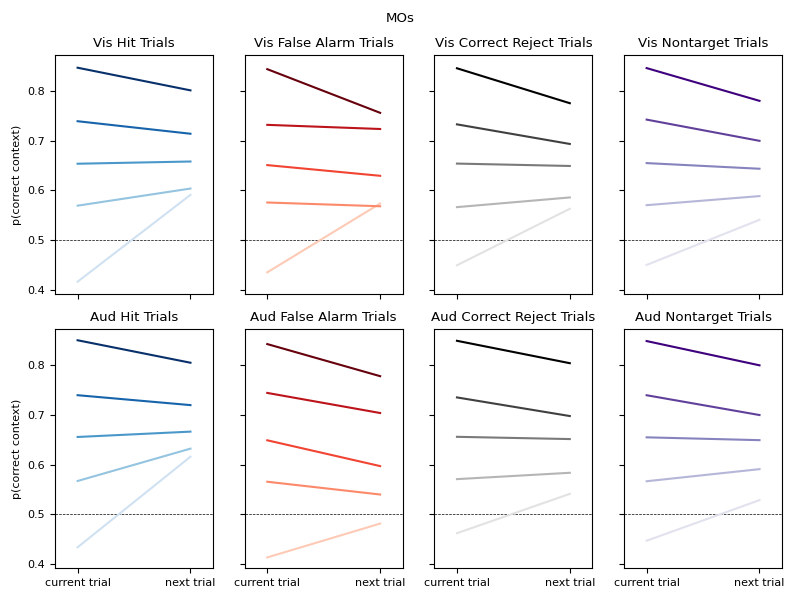

In [29]:
#plot these more specific trial types
fig,ax=plt.subplots(2,4,figsize=(8,6),sharex=True,sharey=True)
ax[0,0].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[0,1].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[0,2].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[0,3].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[1,0].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[1,1].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[1,2].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[1,3].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[0,0].set_title('Vis Hit Trials')
ax[0,1].set_title('Vis False Alarm Trials')
ax[0,2].set_title('Vis Correct Reject Trials')
ax[0,3].set_title('Vis Nontarget Trials')
ax[1,0].set_title('Aud Hit Trials')
ax[1,1].set_title('Aud False Alarm Trials')
ax[1,2].set_title('Aud Correct Reject Trials')
ax[1,3].set_title('Aud Nontarget Trials')
ax[0,0].set_ylabel('p(correct context)')
ax[1,0].set_ylabel('p(correct context)')
ax[1,0].set_xticks([0,1])
ax[1,0].set_xticklabels(['current trial', 'next trial'])
ax[1,0].set_xlim(-0.2,1.2)

for bb in range(len(vis_hit_baseline_bins)-1):
    bin_vis_hits=vis_hit_df.query(f'baseline_bin=={bb}')
    if bin_vis_hits.shape[0]>0:
        ax[0,0].plot([0,1], [np.nanmedian(bin_vis_hits['predict_proba']), np.nanmedian(bin_vis_hits['predict_proba_next'])], 
                label=f'vis hit [{vis_hit_baseline_bins[bb]:.2f}-{vis_hit_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Blues(hit_colors[bb]))
for bb in range(len(aud_hit_baseline_bins)-1):
    bin_aud_hits=aud_hit_df.query(f'baseline_bin=={bb}')
    if bin_aud_hits.shape[0]>0:
        ax[1,0].plot([0,1], [np.nanmedian(bin_aud_hits['predict_proba']), np.nanmedian(bin_aud_hits['predict_proba_next'])], 
                label=f'aud hit [{aud_hit_baseline_bins[bb]:.2f}-{aud_hit_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Blues(hit_colors[bb]))
for bb in range(len(vis_fa_baseline_bins)-1):
    bin_vis_fas=vis_fa_df.query(f'baseline_bin=={bb}')
    if bin_vis_fas.shape[0]>0:
        ax[0,1].plot([0,1], [np.nanmedian(bin_vis_fas['predict_proba']), np.nanmedian(bin_vis_fas['predict_proba_next'])], 
                label=f'vis fa [{vis_fa_baseline_bins[bb]:.2f}-{vis_fa_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Reds(fa_colors[bb]))
for bb in range(len(aud_fa_baseline_bins)-1):
    bin_aud_fas=aud_fa_df.query(f'baseline_bin=={bb}')
    if bin_aud_fas.shape[0]>0:
        ax[1,1].plot([0,1], [np.nanmedian(bin_aud_fas['predict_proba']), np.nanmedian(bin_aud_fas['predict_proba_next'])], 
                label=f'aud fa [{aud_fa_baseline_bins[bb]:.2f}-{aud_fa_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Reds(fa_colors[bb]))
for bb in range(len(vis_cr_baseline_bins)-1):
    bin_vis_crs=vis_cr_df.query(f'baseline_bin=={bb}')
    if bin_vis_crs.shape[0]>0:
        ax[0,2].plot([0,1], [np.nanmedian(bin_vis_crs['predict_proba']), np.nanmedian(bin_vis_crs['predict_proba_next'])], 
                label=f'vis cr [{vis_cr_baseline_bins[bb]:.2f}-{vis_cr_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Greys(cr_colors[bb]))
for bb in range(len(aud_cr_baseline_bins)-1):
    bin_aud_crs=aud_cr_df.query(f'baseline_bin=={bb}')
    if bin_aud_crs.shape[0]>0:
        ax[1,2].plot([0,1], [np.nanmedian(bin_aud_crs['predict_proba']), np.nanmedian(bin_aud_crs['predict_proba_next'])], 
                label=f'aud cr [{aud_cr_baseline_bins[bb]:.2f}-{aud_cr_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Greys(cr_colors[bb]))
for bb in range(len(vis_nontarget_nonresponse_baseline_bins)-1):
    bin_vis_nns=vis_nontarget_nonresponse_df.query(f'baseline_bin=={bb}')
    if bin_vis_nns.shape[0]>0:
        ax[0,3].plot([0,1], [np.nanmedian(bin_vis_nns['predict_proba']), np.nanmedian(bin_vis_nns['predict_proba_next'])], 
                label=f'vis nontarget nonresponse [{vis_nontarget_nonresponse_baseline_bins[bb]:.2f}-{vis_nontarget_nonresponse_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Purples(nn_colors[bb]))
for bb in range(len(aud_nontarget_nonresponse_baseline_bins)-1):
    bin_aud_nns=aud_nontarget_nonresponse_df.query(f'baseline_bin=={bb}')
    if bin_aud_nns.shape[0]>0:
        ax[1,3].plot([0,1], [np.nanmedian(bin_aud_nns['predict_proba']), np.nanmedian(bin_aud_nns['predict_proba_next'])], 
                label=f'aud nontarget nonresponse [{aud_nontarget_nonresponse_baseline_bins[bb]:.2f}-{aud_nontarget_nonresponse_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Purples(nn_colors[bb]))

fig.suptitle(f"{sel_structure}")
fig.tight_layout()

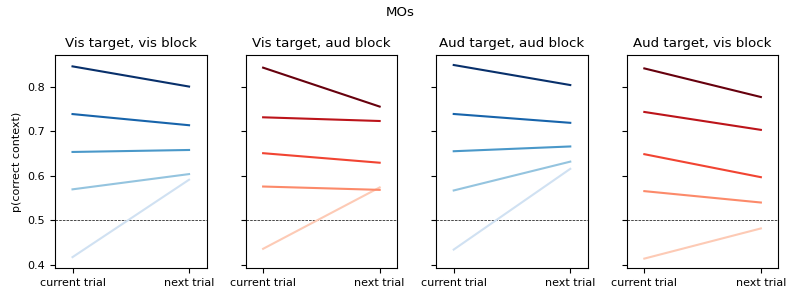

In [30]:
#plot block specific changes

fig,ax=plt.subplots(1,4,figsize=(8,3),sharex=True,sharey=True)
ax[0].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[1].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[2].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[3].axhline(0.5,color='k',linewidth=0.5,linestyle='--')

ax[0].set_title('Vis target, vis block')
ax[1].set_title('Vis target, aud block')
ax[2].set_title('Aud target, aud block')
ax[3].set_title('Aud target, vis block')

for bb in range(len(vis_target_vis_block_response_baseline_bins)-1):
    bin_vis_target_vis_block=vis_target_vis_block_response_df.query(f'baseline_bin=={bb}')
    if bin_vis_target_vis_block.shape[0]>0:
        ax[0].plot([0,1], [np.nanmedian(bin_vis_target_vis_block['predict_proba']), np.nanmedian(bin_vis_target_vis_block['predict_proba_next'])], 
                label=f'vis target vis block [{vis_target_vis_block_response_baseline_bins[bb]:.2f}-{vis_target_vis_block_response_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Blues(hit_colors[bb]))
for bb in range(len(vis_target_aud_block_response_baseline_bins)-1):
    bin_vis_target_aud_block=vis_target_aud_block_response_df.query(f'baseline_bin=={bb}')
    if bin_vis_target_aud_block.shape[0]>0:
        ax[1].plot([0,1], [np.nanmedian(bin_vis_target_aud_block['predict_proba']), np.nanmedian(bin_vis_target_aud_block['predict_proba_next'])], 
                label=f'vis target aud block [{vis_target_aud_block_response_baseline_bins[bb]:.2f}-{vis_target_aud_block_response_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Reds(hit_colors[bb]))
for bb in range(len(aud_target_aud_block_response_baseline_bins)-1):
    bin_aud_target_aud_block=aud_target_aud_block_response_df.query(f'baseline_bin=={bb}')
    if bin_aud_target_aud_block.shape[0]>0:
        ax[2].plot([0,1], [np.nanmedian(bin_aud_target_aud_block['predict_proba']), np.nanmedian(bin_aud_target_aud_block['predict_proba_next'])], 
                label=f'aud target aud block [{aud_target_aud_block_response_baseline_bins[bb]:.2f}-{aud_target_aud_block_response_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Blues(hit_colors[bb]))
for bb in range(len(aud_target_vis_block_response_baseline_bins)-1):
    bin_aud_target_vis_block=aud_target_vis_block_response_df.query(f'baseline_bin=={bb}')
    if bin_aud_target_vis_block.shape[0]>0:
        ax[3].plot([0,1], [np.nanmedian(bin_aud_target_vis_block['predict_proba']), np.nanmedian(bin_aud_target_vis_block['predict_proba_next'])], 
                label=f'aud target vis block [{aud_target_vis_block_response_baseline_bins[bb]:.2f}-{aud_target_vis_block_response_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Reds(hit_colors[bb]))
        
ax[0].set_xticks([0,1])
ax[0].set_xticklabels(['current trial', 'next trial'])
ax[0].set_xlim(-0.15,1.15)
# ax[0].set_ylim(0.2,1.0)
ax[0].set_ylabel('p(correct context)')

fig.suptitle(f"{sel_structure}")
fig.tight_layout()

In [42]:
all_trials_with_decoder_confidence.columns

Index(['start_time', 'stop_time', 'quiescent_start_time',
       'quiescent_stop_time', 'stim_start_time', 'stim_stop_time',
       'response_window_start_time', 'response_window_stop_time',
       'task_control_response_time', 'response_time',
       ...
       'APN_predict_proba', 'DP_predict_proba', 'TTd_predict_proba',
       'TEa_predict_proba', 'RT_predict_proba', 'PAG_predict_proba',
       'RN_predict_proba', 'ILA_predict_proba', 'adj_predict_proba',
       'adj_predict_proba_next'],
      dtype='object', length=107)

In [10]:
# np.sum(~np.isnan(adj_structure_predict_proba))

In [54]:
# Compute forgetting-related columns per session per structure.
# Timing columns (trials/time since last target/informative) are structure-independent.
# Predict_proba reference columns are computed per structure (each has its own _predict_proba column).
#
# Reference anchoring:
#   - trials_since / time_since: updated BEFORE counting so the informative trial itself = 0
#   - pp_at_last_informative: predict_proba ON the informative trial
#   - pp_after_last_informative: predict_proba on the trial AFTER the informative trial
#     (used for normalization because context decoding reflects prestimulus state,
#      which updates and is first visible on the next trial)

# --- Structure-independent timing columns ---
all_trials_with_decoder_confidence['trials_since_last_target'] = np.nan
all_trials_with_decoder_confidence['time_since_last_target'] = np.nan
all_trials_with_decoder_confidence['trials_since_last_informative'] = np.nan
all_trials_with_decoder_confidence['time_since_last_informative'] = np.nan

session_ids_unique = all_trials_with_decoder_confidence['session_id'].unique()

for session_id in session_ids_unique:
    session_mask = all_trials_with_decoder_confidence['session_id'] == session_id
    session_idx = all_trials_with_decoder_confidence.loc[session_mask].index

    trial_indices = all_trials_with_decoder_confidence.loc[session_idx, 'trial_index'].values
    stim_times = all_trials_with_decoder_confidence.loc[session_idx, 'stim_start_time'].values
    is_target = all_trials_with_decoder_confidence.loc[session_idx, 'is_target'].values.astype(bool)
    is_response = all_trials_with_decoder_confidence.loc[session_idx, 'is_response'].values.astype(bool)
    is_informative = is_target & is_response  # hit or FA

    trials_since_target = np.full(len(session_idx), np.nan)
    time_since_target = np.full(len(session_idx), np.nan)
    trials_since_informative = np.full(len(session_idx), np.nan)
    time_since_informative = np.full(len(session_idx), np.nan)

    last_target_pos = None
    last_informative_pos = None

    for i in range(len(session_idx)):
        # update reference positions first so the reference trial itself gets distance=0
        if is_target[i]:
            last_target_pos = i
        if is_informative[i]:
            last_informative_pos = i

        if last_target_pos is not None:
            trials_since_target[i] = trial_indices[i] - trial_indices[last_target_pos]
            time_since_target[i] = stim_times[i] - stim_times[last_target_pos]
        if last_informative_pos is not None:
            trials_since_informative[i] = trial_indices[i] - trial_indices[last_informative_pos]
            time_since_informative[i] = stim_times[i] - stim_times[last_informative_pos]

    all_trials_with_decoder_confidence.loc[session_idx, 'trials_since_last_target'] = trials_since_target
    all_trials_with_decoder_confidence.loc[session_idx, 'time_since_last_target'] = time_since_target
    all_trials_with_decoder_confidence.loc[session_idx, 'trials_since_last_informative'] = trials_since_informative
    all_trials_with_decoder_confidence.loc[session_idx, 'time_since_last_informative'] = time_since_informative

# --- Per-structure: compute adj_predict_proba and reference columns ---
for structure in all_structures:
    pp_col = structure + '_predict_proba'
    adj_col = structure + '_adj_predict_proba'
    ref_target_col = structure + '_pp_at_last_target'
    ref_informative_col = structure + '_pp_at_last_informative'
    ref_after_informative_col = structure + '_pp_after_last_informative'

    if pp_col not in all_trials_with_decoder_confidence.columns:
        continue

    # flip auditory blocks for this structure
    raw_pp = all_trials_with_decoder_confidence[pp_col].values
    adj_pp_all = np.full(len(all_trials_with_decoder_confidence), np.nan)

    for session_id in session_ids_unique:
        session_mask = all_trials_with_decoder_confidence['session_id'] == session_id
        session_pp = raw_pp[session_mask]
        session_block_index = all_trials_with_decoder_confidence.loc[session_mask, 'block_index'].values
        session_labels = all_trials_with_decoder_confidence.loc[session_mask, 'labels'].values

        flipped_pp = decoding_utils.flip_auditory_blocks(
            session_pp, session_block_index, session_labels, input_type='predict_proba')
        adj_pp_all[session_mask] = flipped_pp

    all_trials_with_decoder_confidence[adj_col] = adj_pp_all

    # compute reference predict_proba columns
    pp_at_last_target = np.full(len(all_trials_with_decoder_confidence), np.nan)
    pp_at_last_informative = np.full(len(all_trials_with_decoder_confidence), np.nan)
    pp_after_last_informative = np.full(len(all_trials_with_decoder_confidence), np.nan)

    for session_id in session_ids_unique:
        session_mask = all_trials_with_decoder_confidence['session_id'] == session_id
        session_idx = all_trials_with_decoder_confidence.loc[session_mask].index
        n = len(session_idx)

        is_target = all_trials_with_decoder_confidence.loc[session_idx, 'is_target'].values.astype(bool)
        is_response = all_trials_with_decoder_confidence.loc[session_idx, 'is_response'].values.astype(bool)
        is_informative = is_target & is_response
        adj_pp = adj_pp_all[session_mask]

        last_target_pos = None
        last_informative_pos = None
        session_pp_target = np.full(n, np.nan)
        session_pp_informative = np.full(n, np.nan)
        session_pp_after_informative = np.full(n, np.nan)

        for i in range(n):
            # update first so the reference trial's own pp is used (delta=0 at distance=0)
            if is_target[i]:
                last_target_pos = i
            if is_informative[i]:
                last_informative_pos = i

            if last_target_pos is not None:
                session_pp_target[i] = adj_pp[last_target_pos]
            if last_informative_pos is not None:
                session_pp_informative[i] = adj_pp[last_informative_pos]
                # reference is the trial AFTER the informative trial (first trial
                # whose prestimulus period reflects the updated context state)
                next_pos = last_informative_pos + 1
                if next_pos < n:
                    session_pp_after_informative[i] = adj_pp[next_pos]

        pp_at_last_target[session_mask] = session_pp_target
        pp_at_last_informative[session_mask] = session_pp_informative
        pp_after_last_informative[session_mask] = session_pp_after_informative

    all_trials_with_decoder_confidence[ref_target_col] = pp_at_last_target
    all_trials_with_decoder_confidence[ref_informative_col] = pp_at_last_informative
    all_trials_with_decoder_confidence[ref_after_informative_col] = pp_after_last_informative

    print(f"  {structure}: adj valid={np.sum(~np.isnan(adj_pp_all))}, "
          f"ref_target valid={np.sum(~np.isnan(pp_at_last_target))}, "
          f"ref_informative valid={np.sum(~np.isnan(pp_at_last_informative))}, "
          f"ref_after_informative valid={np.sum(~np.isnan(pp_after_last_informative))}")

print(f"\nDone. Structures processed: {all_structures}")
print(f"Timing columns non-NaN: trials_since_last_target={all_trials_with_decoder_confidence['trials_since_last_target'].notna().sum()}, "
      f"trials_since_last_informative={all_trials_with_decoder_confidence['trials_since_last_informative'].notna().sum()}")

C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_32260\1440960539.py:128: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_trials_with_decoder_confidence[ref_after_informative_col] = pp_after_last_informative


  CA1: adj valid=10966, ref_target valid=10966, ref_informative valid=10966, ref_after_informative valid=10959


C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_32260\1440960539.py:128: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_trials_with_decoder_confidence[ref_after_informative_col] = pp_after_last_informative


  DG: adj valid=11056, ref_target valid=11056, ref_informative valid=11053, ref_after_informative valid=11046


C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_32260\1440960539.py:128: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_trials_with_decoder_confidence[ref_after_informative_col] = pp_after_last_informative


...

C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_32260\1440960539.py:128: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_trials_with_decoder_confidence[ref_after_informative_col] = pp_after_last_informative


  PAG: adj valid=490, ref_target valid=490, ref_informative valid=490, ref_after_informative valid=489


C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_32260\1440960539.py:128: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_trials_with_decoder_confidence[ref_after_informative_col] = pp_after_last_informative


  RN: adj valid=490, ref_target valid=490, ref_informative valid=490, ref_after_informative valid=489
  ILA: adj valid=545, ref_target valid=545, ref_informative valid=545, ref_after_informative valid=545

Done. Structures processed: ['CA1', 'DG', 'VISp', 'CP', 'MOp', 'RSPagl', 'ProS', 'LP', 'MRN', 'RSPd', 'SCm', 'CA3', 'MOs', 'SSp', 'MGm', 'SUB', 'VISl', 'LD', 'RSPv', 'ORBl', 'VPL', 'PIR', 'POST', 'VPM', 'ACAd', 'ACAv', 'FRP', 'ORBvl', 'ORBm', 'PL', 'AId', 'AIv', 'AUDp', 'AUDv', 'PO', 'AON', 'OLF', 'SSs', 'SCs', 'VISC', 'LSr', 'APN', 'DP', 'TTd', 'TEa', 'RT', 'PAG', 'RN', 'ILA']
Timing columns non-NaN: trials_since_last_target=48829, trials_since_last_informative=48815


C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_32260\1440960539.py:128: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_trials_with_decoder_confidence[ref_after_informative_col] = pp_after_last_informative


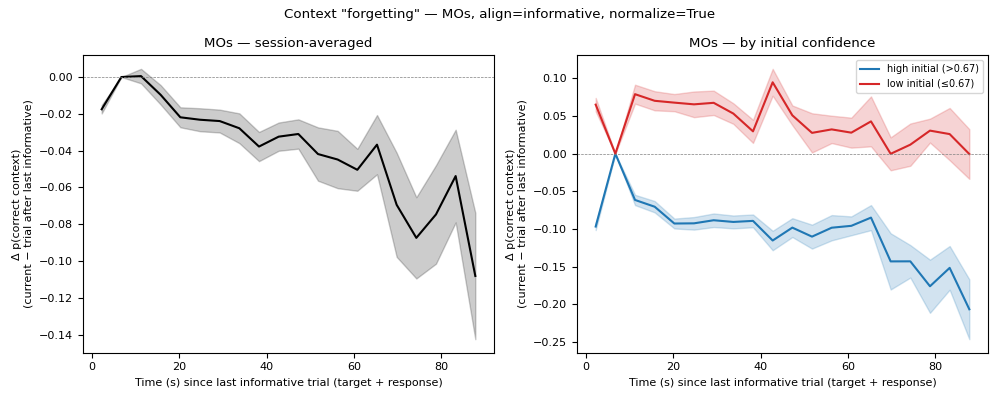

In [66]:
# --- Plot predict_proba vs trials/time since last target & informative trial ---
# Options:
sel_forgetting_structure = 'MOs'        # structure to plot (uses per-structure adj columns)
normalize_to_last_informative = True    # if True, subtract pp of the trial after the last informative trial
x_axis_mode = 'time'                  # 'trials' or 'time'
align_to = 'informative'                # 'target' or 'informative'
max_trials_since = 15                   # max x-axis value (trials)
max_time_since = 90                     # max x-axis value (seconds)

# select columns based on options
adj_col = sel_forgetting_structure + '_adj_predict_proba'
if align_to == 'informative':
    trials_col = 'trials_since_last_informative'
    time_col = 'time_since_last_informative'
    # normalize to the trial AFTER the informative trial: that is the first trial whose
    # prestimulus period reflects the updated context state
    pp_ref_col = sel_forgetting_structure + '_pp_after_last_informative'
    align_label = 'informative trial (target + response)'
else:
    trials_col = 'trials_since_last_target'
    time_col = 'time_since_last_target'
    pp_ref_col = sel_forgetting_structure + '_pp_at_last_target'
    align_label = 'target trial'

x_col = trials_col if x_axis_mode == 'trials' else time_col
x_max = max_trials_since if x_axis_mode == 'trials' else max_time_since
x_label = f'{"Trials" if x_axis_mode == "trials" else "Time (s)"} since last {align_label}'

# filter to valid rows
plot_df = all_trials_with_decoder_confidence.dropna(subset=[x_col, adj_col, pp_ref_col]).copy()
plot_df = plot_df[plot_df[x_col] <= x_max]

if normalize_to_last_informative:
    plot_df['y'] = plot_df[adj_col] - plot_df[pp_ref_col]
    y_label = 'Δ p(correct context)\n(current − trial after last informative)'
else:
    plot_df['y'] = plot_df[adj_col]
    y_label = 'p(correct context)'

# bin x values for cleaner plotting
if x_axis_mode == 'trials':
    plot_df['x_bin'] = plot_df[x_col].astype(int)
else:
    n_time_bins = 20
    plot_df['x_bin'] = pd.cut(plot_df[x_col], bins=n_time_bins, labels=False)
    time_bin_edges = np.linspace(0, x_max, n_time_bins + 1)
    plot_df['x_bin_center'] = plot_df['x_bin'].apply(
        lambda b: (time_bin_edges[int(b)] + time_bin_edges[int(b)+1]) / 2 if pd.notna(b) else np.nan)

# compute session-wise averages per x_bin, then grand average +/- SEM
session_avg = plot_df.groupby(['session_id', 'x_bin'])['y'].mean().reset_index()
grand_avg = session_avg.groupby('x_bin')['y'].agg(['mean', 'sem', 'count']).reset_index()
grand_avg = grand_avg[grand_avg['count'] >= 5]  # require at least 5 sessions per bin

if x_axis_mode == 'time':
    grand_avg['x_plot'] = grand_avg['x_bin'].apply(
        lambda b: (time_bin_edges[int(b)] + time_bin_edges[int(b)+1]) / 2 if pd.notna(b) else np.nan)
else:
    grand_avg['x_plot'] = grand_avg['x_bin']

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left panel: grand average across sessions
ax = axes[0]
ax.plot(grand_avg['x_plot'], grand_avg['mean'], 'k-', linewidth=1.5)
ax.fill_between(grand_avg['x_plot'],
                grand_avg['mean'] - grand_avg['sem'],
                grand_avg['mean'] + grand_avg['sem'],
                color='k', alpha=0.2)
ax.axhline(0 if normalize_to_last_informative else 0.5, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.set_title(f'{sel_forgetting_structure} — session-averaged')

# Right panel: split by initial confidence (high vs. low at trial after last informative)
ax2 = axes[1]
median_ref = plot_df[pp_ref_col].median()
for label, mask, color in [
    (f'high initial (>{median_ref:.2f})', plot_df[pp_ref_col] > median_ref, 'tab:blue'),
    (f'low initial (≤{median_ref:.2f})', plot_df[pp_ref_col] <= median_ref, 'tab:red'),
]:
    sub = plot_df.loc[mask]
    sub_session_avg = sub.groupby(['session_id', 'x_bin'])['y'].mean().reset_index()
    sub_grand = sub_session_avg.groupby('x_bin')['y'].agg(['mean', 'sem', 'count']).reset_index()
    sub_grand = sub_grand[sub_grand['count'] >= 5]
    if x_axis_mode == 'time':
        sub_grand['x_plot'] = sub_grand['x_bin'].apply(
            lambda b: (time_bin_edges[int(b)] + time_bin_edges[int(b)+1]) / 2 if pd.notna(b) else np.nan)
    else:
        sub_grand['x_plot'] = sub_grand['x_bin']
    ax2.plot(sub_grand['x_plot'], sub_grand['mean'], '-', color=color, linewidth=1.5, label=label)
    ax2.fill_between(sub_grand['x_plot'],
                     sub_grand['mean'] - sub_grand['sem'],
                     sub_grand['mean'] + sub_grand['sem'],
                     color=color, alpha=0.2)

ax2.axhline(0 if normalize_to_last_informative else 0.5, color='grey', linewidth=0.5, linestyle='--')
ax2.set_xlabel(x_label)
ax2.set_ylabel(y_label)
ax2.set_title(f'{sel_forgetting_structure} — by initial confidence')
ax2.legend(fontsize=7)

fig.suptitle(f'Context "forgetting" — {sel_forgetting_structure}, align={align_to}, normalize={normalize_to_last_informative}')
fig.tight_layout()